# HGCAL regression with gradient boosting

This notebook turns the per-layer calorimeter summary features into a tabular regression problem and fits a gradient-boosting baseline.


In [7]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


## 1. Load the main training sample


In [8]:
DATA_PATH = Path("hgcal_electron_data_10000.csv")
df = pd.read_csv(DATA_PATH)


## 2. Inspect correlations between input features


In [9]:
import seaborn as sn
import matplotlib.pyplot as plt
%matplotlib inline
features_corr = ['energySum_layer0', 'energySum_layer1', 'energySum_layer2', 'energySum_layer3', 'energySum_layer4', 'energySum_layer5', 'energySum_layer6', 'energySum_layer7', 'energySum_layer8', 'energySum_layer9', 'energySum_layer10', 'energySum_layer11', 'energySum_layer12', 'energySum_layer13', 'energySum_layer14', 'energySum_layer15', 'energySum_layer16', 'energySum_layer17', 'energySum_layer18', 'energySum_layer19', 'energySum_layer20', 'energySum_layer21', 'energySum_layer22', 'energySum_layer23', 'energySum_layer24', 'energySum_layer25', 'energySum_layer26', 'energySum_layer27', 'rMean_layer0', 'rMean_layer1', 'rMean_layer2', 'rMean_layer3', 'rMean_layer4', 'rMean_layer5', 'rMean_layer6', 'rMean_layer7', 'rMean_layer8', 'rMean_layer9', 'rMean_layer10', 'rMean_layer11', 'rMean_layer12', 'rMean_layer13', 'rMean_layer14', 'rMean_layer15', 'rMean_layer16', 'rMean_layer17', 'rMean_layer18', 'rMean_layer19', 'rMean_layer20', 'rMean_layer21', 'rMean_layer22', 'rMean_layer23', 'rMean_layer24', 'rMean_layer25', 'rMean_layer26', 'rMean_layer27', 'rStd_layer0', 'rStd_layer1', 'rStd_layer2', 'rStd_layer3', 'rStd_layer4', 'rStd_layer5', 'rStd_layer6', 'rStd_layer7', 'rStd_layer8', 'rStd_layer9', 'rStd_layer10', 'rStd_layer11', 'rStd_layer12', 'rStd_layer13', 'rStd_layer14', 'rStd_layer15', 'rStd_layer16', 'rStd_layer17', 'rStd_layer18', 'rStd_layer19', 'rStd_layer20', 'rStd_layer21', 'rStd_layer22', 'rStd_layer23', 'rStd_layer24', 'rStd_layer25', 'rStd_layer26', 'rStd_layer27', 'nhits_total', 'target_energy']

df_corr=df[features_corr]
corr=df_corr.corr()
f, ax=plt.subplots(figsize=(100,100))
plt.rcParams.update({'font.size': 6})
sn.heatmap(corr, cmap = 'coolwarm', vmin = -1, vmax = 1, center = 0, annot=True, fmt=".2f", square=True, linewidths=.5)
#plt.savefig("corr_matrix_hgcal_project.png")


<Axes: >

## 3. Choose the regression features


In [10]:
#df = df.dropna()

#features_train = ['energySum_layer0', 'energySum_layer1', 'energySum_layer2', 'energySum_layer3', 'energySum_layer4', 'energySum_layer5', 'energySum_layer6', 'energySum_layer7', 'energySum_layer8', 'energySum_layer9', 'energySum_layer10', 'energySum_layer11', 'energySum_layer12', 'energySum_layer13', 'energySum_layer14', 'energySum_layer15', 'energySum_layer16', 'energySum_layer17', 'energySum_layer18', 'energySum_layer19', 'energySum_layer20', 'energySum_layer21', 'energySum_layer22', 'energySum_layer23', 'energySum_layer24', 'energySum_layer25', 'energySum_layer26', 'energySum_layer27', 'nhits_total', 'xMean_layer0', 'xMean_layer1', 'xMean_layer2', 'xMean_layer3', 'xMean_layer4', 'xMean_layer5', 'xMean_layer6', 'xMean_layer7', 'xMean_layer8', 'xMean_layer9', 'xMean_layer10', 'xMean_layer11', 'xMean_layer12', 'xMean_layer13', 'xMean_layer14', 'xMean_layer15', 'xMean_layer16', 'xMean_layer17', 'xMean_layer18', 'xMean_layer19', 'xMean_layer20', 'xMean_layer21', 'xMean_layer22', 'xMean_layer23', 'xMean_layer24', 'xMean_layer25', 'xMean_layer26', 'xMean_layer27', 'yMean_layer0', 'yMean_layer1', 'yMean_layer2', 'yMean_layer3', 'yMean_layer4', 'yMean_layer5', 'yMean_layer6', 'yMean_layer7', 'yMean_layer8', 'yMean_layer9', 'yMean_layer10', 'yMean_layer11', 'yMean_layer12', 'yMean_layer13', 'yMean_layer14', 'yMean_layer15', 'yMean_layer16', 'yMean_layer17', 'yMean_layer18', 'yMean_layer19', 'yMean_layer20', 'yMean_layer21', 'yMean_layer22', 'yMean_layer23', 'yMean_layer24', 'yMean_layer25', 'yMean_layer26', 'yMean_layer27']
features_train = ['energySum_layer0', 'energySum_layer1', 'energySum_layer2', 'energySum_layer3', 'energySum_layer4', 'energySum_layer5', 'energySum_layer6', 'energySum_layer7', 'energySum_layer8', 'energySum_layer9', 'energySum_layer10', 'energySum_layer11', 'energySum_layer12', 'energySum_layer13', 'energySum_layer14', 'energySum_layer15', 'energySum_layer16', 'energySum_layer17', 'energySum_layer18', 'energySum_layer19', 'energySum_layer20', 'energySum_layer21', 'energySum_layer22', 'energySum_layer23', 'energySum_layer24', 'energySum_layer25', 'energySum_layer26', 'energySum_layer27', 'rMean_layer0', 'rMean_layer1', 'rMean_layer2', 'rMean_layer3', 'rMean_layer4', 'rMean_layer5', 'rMean_layer6', 'rMean_layer7', 'rMean_layer8', 'rMean_layer9', 'rMean_layer10', 'rMean_layer11', 'rMean_layer12', 'rMean_layer13', 'rMean_layer14', 'rMean_layer15', 'rMean_layer16', 'rMean_layer17', 'rMean_layer18', 'rMean_layer19', 'rMean_layer20', 'rMean_layer21', 'rMean_layer22', 'rMean_layer23', 'rMean_layer24', 'rMean_layer25', 'rMean_layer26', 'rMean_layer27', 'rStd_layer0', 'rStd_layer1', 'rStd_layer2', 'rStd_layer3', 'rStd_layer4', 'rStd_layer5', 'rStd_layer6', 'rStd_layer7', 'rStd_layer8', 'rStd_layer9', 'rStd_layer10', 'rStd_layer11', 'rStd_layer12', 'rStd_layer13', 'rStd_layer14', 'rStd_layer15', 'rStd_layer16', 'rStd_layer17', 'rStd_layer18', 'rStd_layer19', 'rStd_layer20', 'rStd_layer21', 'rStd_layer22', 'rStd_layer23', 'rStd_layer24', 'rStd_layer25', 'rStd_layer26', 'rStd_layer27', 'nhits_total', 'target_energy']
df_train = df[features_train] 
df_train = df_train.drop('target_energy', axis=1)

#print(df_train.head(4).T)

X = np.array(df_train)
y = np.array(df['target_energy'])

print("Shape of X = {0}, Shape of y = {1}".format(X.shape, y.shape))
print(y)


Shape of X = (10000, 85), Shape of y = (10000,)
[286.60653027 260.23076694 122.32089501 ... 173.98600072  38.72558902
 263.59380907]


## 4. Split into training and test sets


In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

print("Shape of X_train = {0}, Shape of y_train = {1}".format(X_train.shape, y_train.shape))
print("Shape of X_test = {0}, Shape of y_test = {1}".format(X_test.shape, y_test.shape))


Shape of X_train = (7000, 85), Shape of y_train = (7000,)
Shape of X_test = (3000, 85), Shape of y_test = (3000,)


## 5. Configure the model


In [12]:
from sklearn import datasets, ensemble
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

params = {
    "n_estimators": 2000,
    "max_depth": 3,
    "min_samples_split": 5,
    "learning_rate": 0.001,
    "loss": "squared_error",
    "verbose": 1
}
#param_dict={'objective':'multi:softprob', 'n_estimators':200, 'learning_rate':0.1, 'max_depth':6, 'gamma':0, 'n_jobs':10, 'num_class':2}
#clf=xgb.XGBClassifier(use_label_encoder=False, **param_dict)
#clf.fit(X_train, y_train)


## 6. Fit the regressor and measure test error


In [13]:
reg = ensemble.GradientBoostingRegressor(**params)
reg.fit(X_train, y_train)

mse = mean_squared_error(y_test, reg.predict(X_test))
print("The mean squared error (MSE) on test set: {:.4f}".format(mse))


      Iter       Train Loss   Remaining Time 
         1        9320.1112            5.50m
         2        9302.1678            5.50m
         3        9284.2603            5.41m
         4        9266.3885            5.36m
         5        9248.5525            5.32m
         6        9230.7521            5.34m
         7        9212.9872            5.51m
         8        9195.2578            5.49m
         9        9177.5639            5.47m
        10        9159.9053            5.45m
        20        8985.2449            5.43m
        30        8814.0264            5.43m
        40        8646.1909            5.45m
        50        8481.6399            5.46m
        60        8320.3121            5.43m
        70        8162.0911            5.40m
        80        8006.9595            5.36m
        90        7854.8473            5.32m
       100        7705.7036            5.28m
       200        6364.3164            4.90m
       300        5261.5402            4.61m
       40

## 7. Compare train and test scores


In [14]:
# Get the score on the training set
train_score = reg.score(X_train, y_train)
print(f"Training score: {train_score:.4f}")

# Get the score on the test set
test_score = reg.score(X_test, y_test)
print(f"Test score: {test_score:.4f}")


Training score: 0.9706
Test score: 0.9696


## 8. Inspect predictions directly


In [15]:
# Make predictions
y_pred_train = reg.predict(X_train)
y_pred_test = reg.predict(X_test)

# Print the predicted values for the training set
print("Predicted values for the training set:")
print(y_pred_train)

# Print the predicted values for the test set
print("Predicted values for the test set:")
print(y_pred_test)


Predicted values for the training set:
[224.4257126   62.99387868 144.10832083 ... 241.55683912  46.08048842
 283.11587364]
Predicted values for the test set:
[134.64715401  90.05874038  46.50100791 ...  69.67373835  46.34475559
 252.84309078]


## 9. Plot predicted vs. true energy


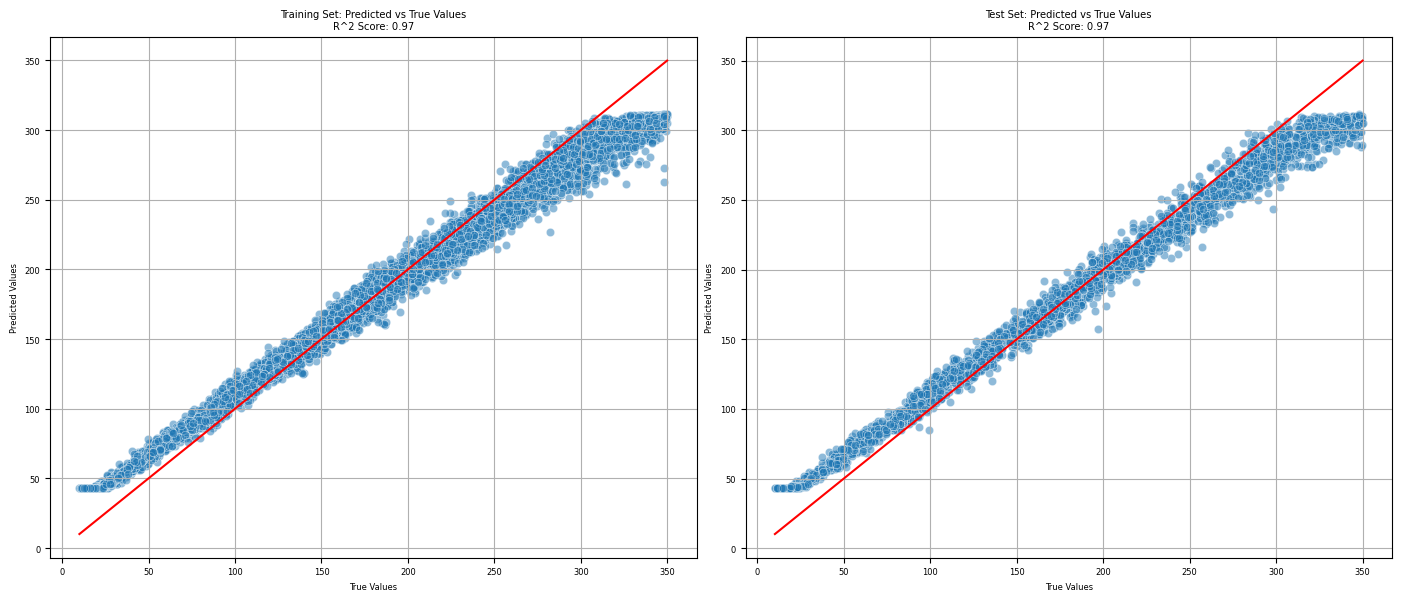

In [16]:
# Plot predicted vs. true values for the test set
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_regression
from sklearn.metrics import r2_score

# Calculate R^2 scores
train_r2 = r2_score(y_train, y_pred_train)
test_r2 = r2_score(y_test, y_pred_test)

# Plot predicted vs. true values for the training set
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.scatterplot(x=y_train, y=y_pred_train, alpha=0.5)
sns.lineplot(x=y_train, y=y_train, color='red')  # Plotting y = x line
plt.xlabel('True Values')
plt.ylabel('Predicted Values')
plt.title(f'Training Set: Predicted vs True Values\nR^2 Score: {train_r2:.2f}')
plt.grid(True)

# Plot predicted vs. true values for the test set
plt.subplot(1, 2, 2)
sns.scatterplot(x=y_test, y=y_pred_test, alpha=0.5)
sns.lineplot(x=y_test, y=y_test, color='red')  # Plotting y = x line
plt.xlabel('True Values')
plt.ylabel('Predicted Values')
plt.title(f'Test Set: Predicted vs True Values\nR^2 Score: {test_r2:.2f}')
plt.grid(True)

plt.tight_layout()
plt.show()


## 10. Look at the relative error distribution


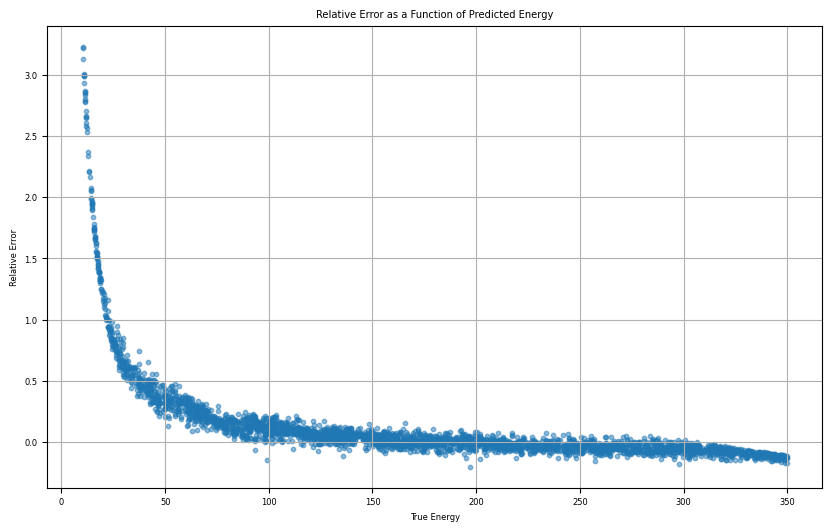

Energy Resolution (Standard Deviation of Relative Error): 0.39370773509961077


In [34]:
import numpy as np
import matplotlib.pyplot as plt


relative_error = (y_pred_test - y_test) / y_test


plt.figure(figsize=(10, 6))
plt.scatter(y_test, relative_error, s=10, alpha=0.5)
plt.xlabel('True Energy')
plt.ylabel('Relative Error')
plt.title('Relative Error as a Function of Predicted Energy')
plt.grid(True)
plt.show()


energy_resolution = np.std(relative_error)
print(f"Energy Resolution (Standard Deviation of Relative Error): {energy_resolution}")


## 11. Check the test-range bounds


In [20]:
y_min = np.min(y_test)
y_max = np.max(y_test)

print(f"Minimum value of y_test: {y_min}")
print(f"Maximum value of y_test: {y_max}")


Minimum value of y_test: 10.19686008939807
Maximum value of y_test: 349.9999732905983


## 12. Inspect auxiliary BDT outputs


In [21]:
import pandas as pd

# Replace 'your_file.csv' with the path to your CSV file
file_path = Path("BDT_energy_50K.csv")

# Read the CSV file into a DataFrame
df = pd.read_csv(file_path)

# Display the first few rows of the DataFrame
print(df.head())


         true        pred
0   54.955074   54.799706
1  256.954217  262.325152
2  113.585323  118.897488
3  112.687488  115.786259
4   36.866458   34.289877


## 13. Plot the true-energy histogram


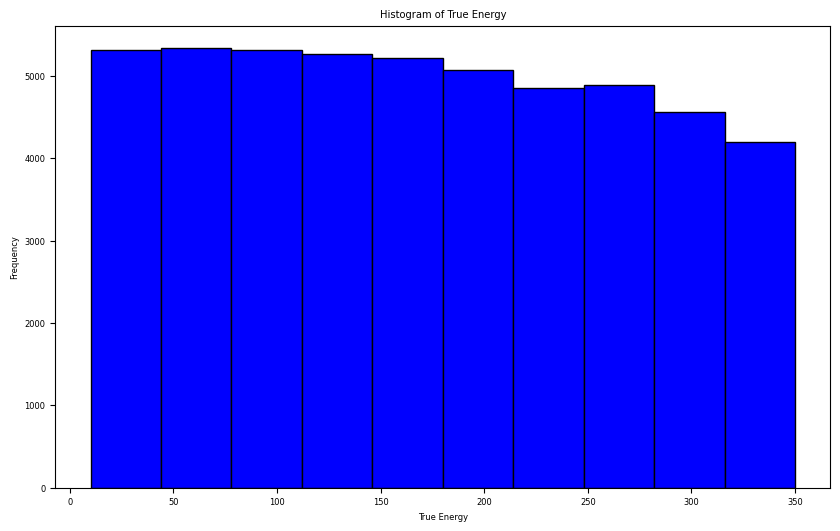

In [23]:
plt.figure(figsize=(10, 6))
plt.hist(df['true'], bins=10, color='blue', edgecolor='black')
plt.xlabel('True Energy')
plt.ylabel('Frequency')
plt.title('Histogram of True Energy')
plt.show()


## 14. Inspect the BDT output distribution


/tmp/ipykernel_16710/4171159208.py:36: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  bin_df['ratio'] = bin_df['pred'] / bin_df['true']
/tmp/ipykernel_16710/4171159208.py:36: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  bin_df['ratio'] = bin_df['pred'] / bin_df['true']
/tmp/ipykernel_16710/4171159208.py:36: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.p

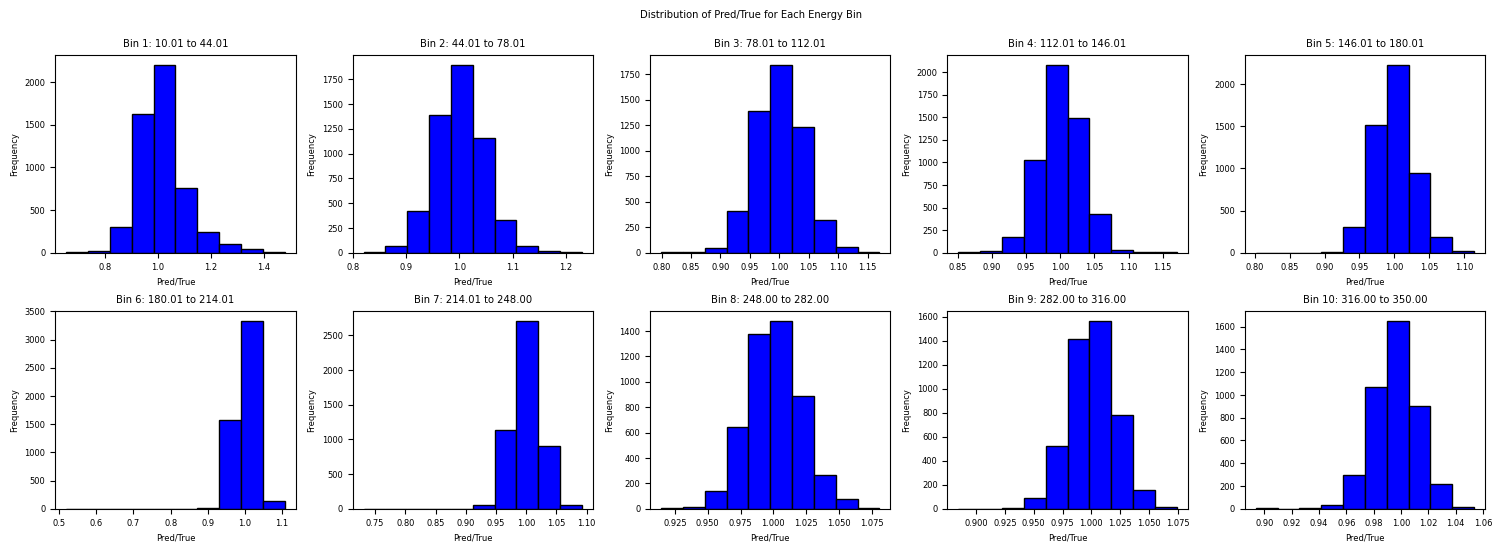

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Replace 'your_file.csv' with the path to your CSV file
file_path = Path("BDT_energy_50K.csv")


# Read the CSV file into a DataFrame
df = pd.read_csv(file_path)

# Define the number of bins
num_bins = 10

# Create the histogram and get the bin edges
counts, bin_edges = np.histogram(df['true'], bins=num_bins)

# Create a list to store DataFrames for each bin
bin_dataframes = []

# Create a figure for the subplots
plt.figure(figsize=(15, 10))

# Iterate over the bin edges to filter the data and plot the distribution
for i in range(len(bin_edges) - 1):
    bin_start = bin_edges[i]
    bin_end = bin_edges[i + 1]
    
    # Filter the DataFrame for the current bin
    bin_df = df[(df['true'] >= bin_start) & (df['true'] < bin_end)]
    
    # Store the filtered DataFrame in the list
    bin_dataframes.append(bin_df)
    
    # Calculate the ratio pred/true
    bin_df['ratio'] = bin_df['pred'] / bin_df['true']
    
    # Create a subplot for the current bin
    plt.subplot(4, 5, i + 1)
    plt.hist(bin_df['ratio'], bins=10, color='blue', edgecolor='black')
    plt.xlabel('Pred/True')
    plt.ylabel('Frequency')
    plt.title(f'Bin {i+1}: {bin_start:.2f} to {bin_end:.2f}')
    plt.tight_layout()

# Display the plots
plt.suptitle('Distribution of Pred/True for Each Energy Bin', y=1.02)
plt.show()

# Now bin_dataframes contains separate DataFrames for each bin
# You can access them using bin_dataframes[0], bin_dataframes[1], etc.


## 15. Compare the BDT response to a Gaussian


/tmp/ipykernel_16710/589317129.py:41: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  bin_df['ratio'] = bin_df['pred'] / bin_df['true']
/tmp/ipykernel_16710/589317129.py:41: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  bin_df['ratio'] = bin_df['pred'] / bin_df['true']
/tmp/ipykernel_16710/589317129.py:41: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pyda

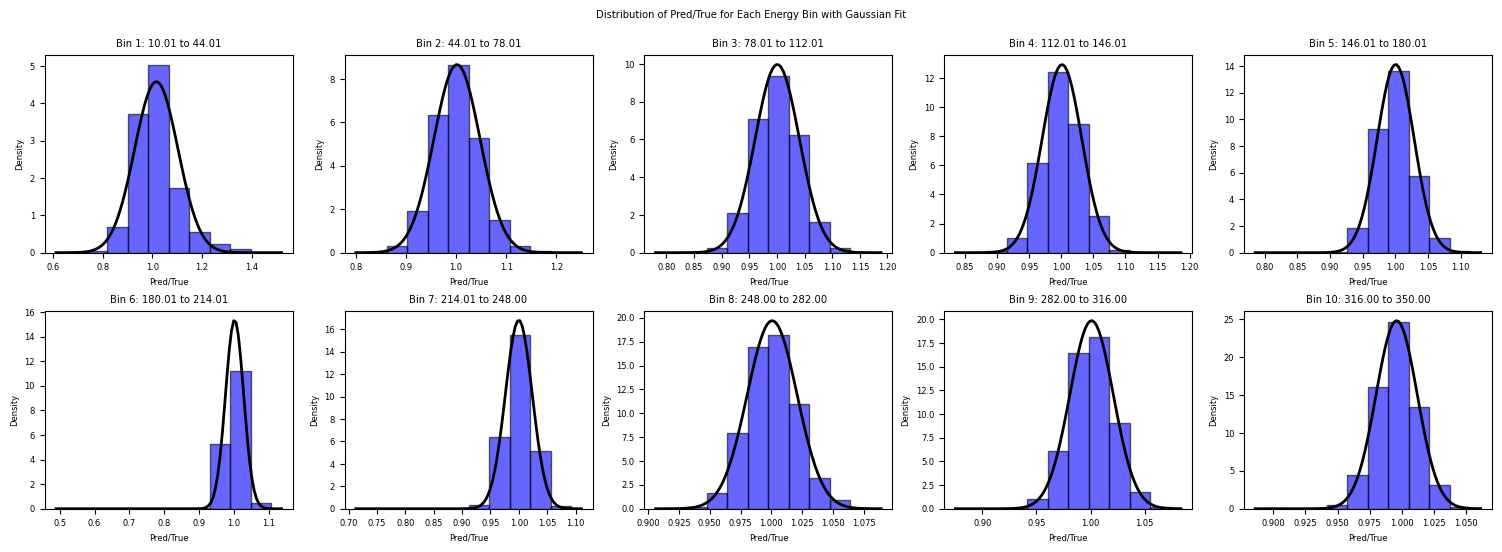

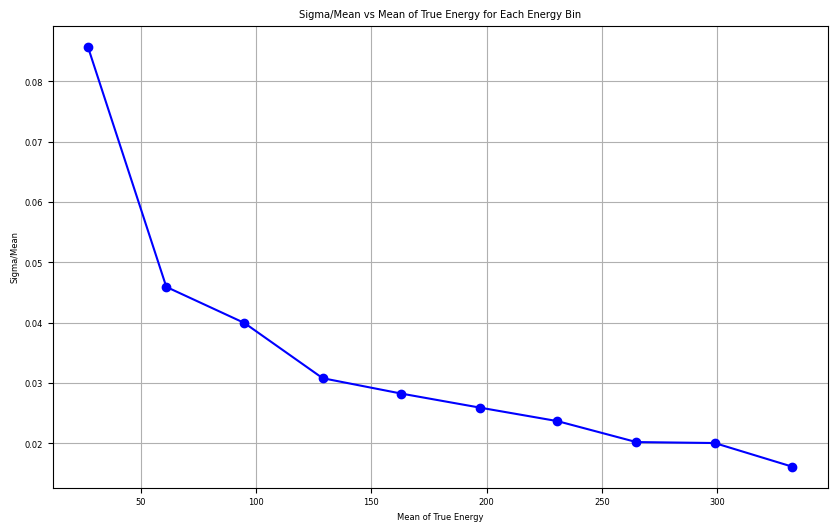

Means of True Energy: [27.069589717118127, 61.09048873011723, 94.97922999204572, 128.91271691270904, 163.01411830011355, 197.16313356375463, 230.7508356113899, 264.93589051036383, 298.92759742901404, 332.65349207293315]
Means of Pred/True Ratios: [1.0161026049270452, 1.0017061430612635, 1.000573670570502, 1.0010427513087718, 1.0002966125010515, 1.0013950879485545, 1.000080927840468, 1.0006478843242224, 1.000992012400893, 0.9961094572191552]
Sigmas of Pred/True Ratios: [0.08713235740759995, 0.046026701471766136, 0.0399884417874152, 0.030850581806865684, 0.02827803993240288, 0.025976479038638433, 0.023707667042559815, 0.020248148192666297, 0.02009704226965312, 0.01608735286964905]
Sigma/Mean Ratios: [0.08575153432842142, 0.04594830708645378, 0.039965514747769444, 0.030818445832139905, 0.02826965479938897, 0.025940290052604037, 0.023705748587519948, 0.020235038228597946, 0.02007712551217076, 0.016150185858650724]


In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm

# Replace 'your_file.csv' with the path to your CSV file
file_path = Path("BDT_energy_50K.csv")

# Read the CSV file into a DataFrame
df = pd.read_csv(file_path)

# Define the number of bins
num_bins = 10

# Create the histogram and get the bin edges
counts, bin_edges = np.histogram(df['true'], bins=num_bins)

# Create a list to store DataFrames for each bin
bin_dataframes = []

# Create arrays to store the mean and sigma for each bin
means = []
sigmas = []
mean_true_energies = []

# Create a figure for the subplots
plt.figure(figsize=(15, 10))

# Iterate over the bin edges to filter the data and plot the distribution
for i in range(len(bin_edges) - 1):
    bin_start = bin_edges[i]
    bin_end = bin_edges[i + 1]
    
    # Filter the DataFrame for the current bin
    bin_df = df[(df['true'] >= bin_start) & (df['true'] < bin_end)]
    
    # Store the filtered DataFrame in the list
    bin_dataframes.append(bin_df)
    
    # Calculate the ratio pred/true
    bin_df['ratio'] = bin_df['pred'] / bin_df['true']
    
    # Fit a Gaussian distribution to the ratio data
    mean, sigma = norm.fit(bin_df['ratio'])
    
    # Store the mean and sigma in the arrays
    means.append(mean)
    sigmas.append(sigma)
    
    # Calculate the mean of the true energy for the current bin
    mean_true_energy = bin_df['true'].mean()
    mean_true_energies.append(mean_true_energy)
    
    # Create a subplot for the current bin
    plt.subplot(4, 5, i + 1)
    # Plot the histogram
    plt.hist(bin_df['ratio'], bins=10, density=True, color='blue', edgecolor='black', alpha=0.6)
    # Plot the Gaussian fit
    xmin, xmax = plt.xlim()
    x = np.linspace(xmin, xmax, 100)
    p = norm.pdf(x, mean, sigma)
    plt.plot(x, p, 'k', linewidth=2)
    
    plt.xlabel('Pred/True')
    plt.ylabel('Density')
    plt.title(f'Bin {i+1}: {bin_start:.2f} to {bin_end:.2f}')
    plt.tight_layout()

# Display the plots
plt.suptitle('Distribution of Pred/True for Each Energy Bin with Gaussian Fit', y=1.02)
plt.show()

# Calculate sigma/mean for each bin
sigma_over_mean = [sigma / mean for sigma, mean in zip(sigmas, means)]

# Plot sigma/mean as a function of the mean of true energy
plt.figure(figsize=(10, 6))
plt.plot(mean_true_energies, sigma_over_mean, marker='o', linestyle='-', color='b')
plt.xlabel('Mean of True Energy')
plt.ylabel('Sigma/Mean')
plt.title('Sigma/Mean vs Mean of True Energy for Each Energy Bin')
plt.grid(True)
plt.show()

# Print the means and sigmas
print("Means of True Energy:", mean_true_energies)
print("Means of Pred/True Ratios:", means)
print("Sigmas of Pred/True Ratios:", sigmas)
print("Sigma/Mean Ratios:", sigma_over_mean)


## 16. Repeat the comparison on the DNN output


/tmp/ipykernel_16710/427509610.py:45: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  bin_df['ratio'] = bin_df['pred'] / bin_df['true']
/tmp/ipykernel_16710/427509610.py:45: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  bin_df['ratio'] = bin_df['pred'] / bin_df['true']
/tmp/ipykernel_16710/427509610.py:45: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pyda

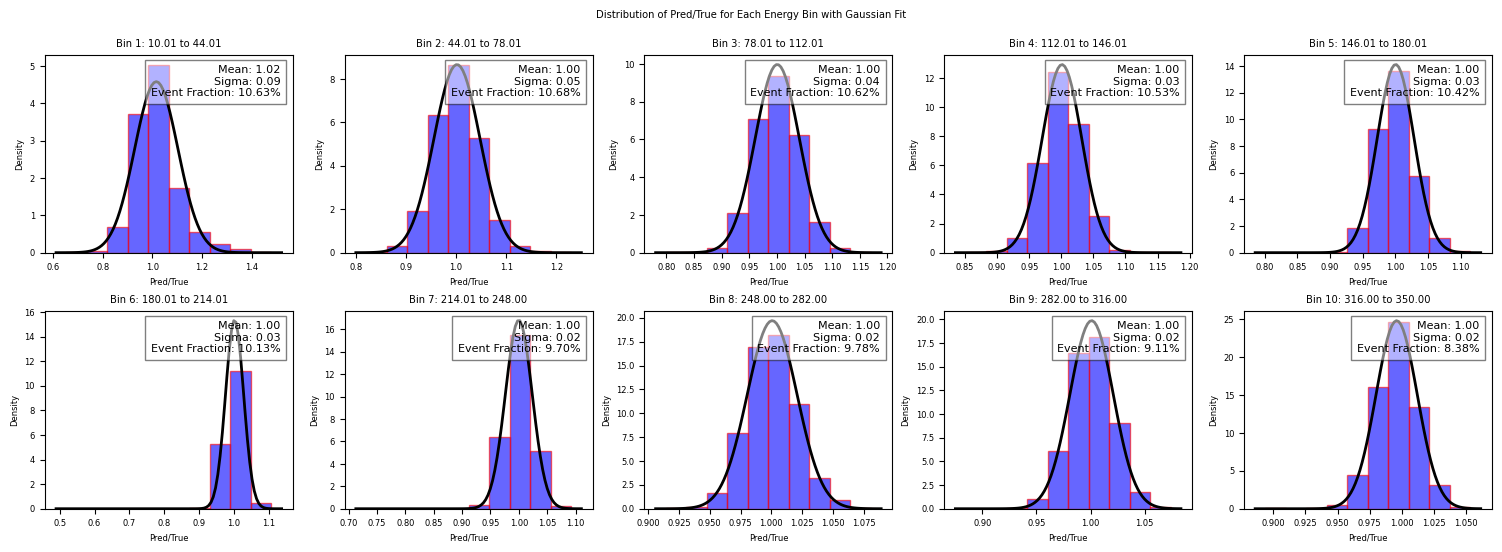

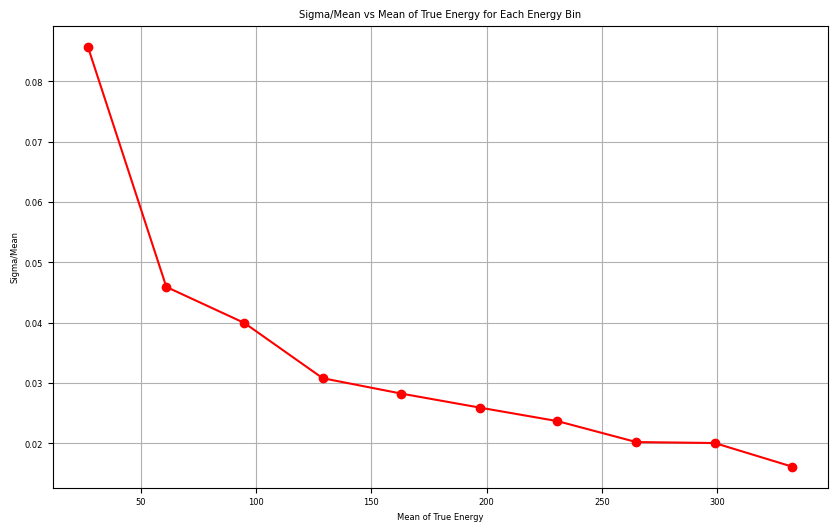

Means of True Energy: [27.069589717118127, 61.09048873011723, 94.97922999204572, 128.91271691270904, 163.01411830011355, 197.16313356375463, 230.7508356113899, 264.93589051036383, 298.92759742901404, 332.65349207293315]
Means of Pred/True Ratios: [1.0161026049270452, 1.0017061430612635, 1.000573670570502, 1.0010427513087718, 1.0002966125010515, 1.0013950879485545, 1.000080927840468, 1.0006478843242224, 1.000992012400893, 0.9961094572191552]
Sigmas of Pred/True Ratios: [0.08713235740759995, 0.046026701471766136, 0.0399884417874152, 0.030850581806865684, 0.02827803993240288, 0.025976479038638433, 0.023707667042559815, 0.020248148192666297, 0.02009704226965312, 0.01608735286964905]
Event Fractions: [0.10632, 0.10684, 0.10624, 0.10526, 0.10424, 0.10132, 0.09702, 0.09776, 0.09114, 0.08384]
Sigma/Mean Ratios: [0.08575153432842142, 0.04594830708645378, 0.039965514747769444, 0.030818445832139905, 0.02826965479938897, 0.025940290052604037, 0.023705748587519948, 0.020235038228597946, 0.020077125

In [35]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm

# Replace 'your_file.csv' with the path to your CSV file
file_path = Path("BDT_energy_50K.csv")

# Read the CSV file into a DataFrame
df = pd.read_csv(file_path)

# Define the number of bins
num_bins = 10

# Create the histogram and get the bin edges
counts, bin_edges = np.histogram(df['true'], bins=num_bins)

# Create a list to store DataFrames for each bin
bin_dataframes = []

# Create arrays to store the mean and sigma for each bin
means = []
sigmas = []
mean_true_energies = []
event_fractions = []

# Calculate the total number of events
total_events = len(df)

# Create a figure for the subplots
plt.figure(figsize=(15, 10))

# Iterate over the bin edges to filter the data and plot the distribution
for i in range(len(bin_edges) - 1):
    bin_start = bin_edges[i]
    bin_end = bin_edges[i + 1]
    
    # Filter the DataFrame for the current bin
    bin_df = df[(df['true'] >= bin_start) & (df['true'] < bin_end)]
    
    # Store the filtered DataFrame in the list
    bin_dataframes.append(bin_df)
    
    # Calculate the ratio pred/true
    bin_df['ratio'] = bin_df['pred'] / bin_df['true']
    
    # Fit a Gaussian distribution to the ratio data
    mean, sigma = norm.fit(bin_df['ratio'])
    
    # Store the mean and sigma in the arrays
    means.append(mean)
    sigmas.append(sigma)
    
    # Calculate the mean of the true energy for the current bin
    mean_true_energy = bin_df['true'].mean()
    mean_true_energies.append(mean_true_energy)
    
    # Calculate the event fraction for the current bin
    event_fraction = len(bin_df) / total_events
    event_fractions.append(event_fraction)
    
    # Create a subplot for the current bin
    plt.subplot(4, 5, i + 1)
    # Plot the histogram
    plt.hist(bin_df['ratio'], bins=10, density=True, color='blue', edgecolor='red', alpha=0.6)
    # Plot the Gaussian fit
    xmin, xmax = plt.xlim()
    x = np.linspace(xmin, xmax, 100)
    p = norm.pdf(x, mean, sigma)
    plt.plot(x, p, 'k', linewidth=2)
    
    plt.xlabel('Pred/True')
    plt.ylabel('Density')
    plt.title(f'Bin {i+1}: {bin_start:.2f} to {bin_end:.2f}')
    
    # Add a stats box
    textstr = '\n'.join((
        f'Mean: {mean:.2f}',
        f'Sigma: {sigma:.2f}',
        f'Event Fraction: {event_fraction:.2%}'
    ))
    plt.text(0.95, 0.95, textstr, transform=plt.gca().transAxes, fontsize=8,
             verticalalignment='top', horizontalalignment='right', bbox=dict(facecolor='white', alpha=0.5))
    
    plt.tight_layout()

# Display the plots
plt.suptitle('Distribution of Pred/True for Each Energy Bin with Gaussian Fit', y=1.02)
plt.show()

# Calculate sigma/mean for each bin
sigma_over_mean = [sigma / mean for sigma, mean in zip(sigmas, means)]

# Plot sigma/mean as a function of the mean of true energy
plt.figure(figsize=(10, 6))
plt.plot(mean_true_energies, sigma_over_mean, marker='o', linestyle='-', color='r')
plt.xlabel('Mean of True Energy')
plt.ylabel('Sigma/Mean')
plt.title('Sigma/Mean vs Mean of True Energy for Each Energy Bin')
plt.grid(True)
plt.show()

# Print the means, sigmas, and event fractions
print("Means of True Energy:", mean_true_energies)
print("Means of Pred/True Ratios:", means)
print("Sigmas of Pred/True Ratios:", sigmas)
print("Event Fractions:", event_fractions)
print("Sigma/Mean Ratios:", sigma_over_mean)


## 17. Inspect the held-out DNN predictions


/tmp/ipykernel_16710/1820299680.py:45: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  bin_df['ratio'] = bin_df['pred'] / bin_df['true']
/tmp/ipykernel_16710/1820299680.py:45: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  bin_df['ratio'] = bin_df['pred'] / bin_df['true']
/tmp/ipykernel_16710/1820299680.py:45: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.p

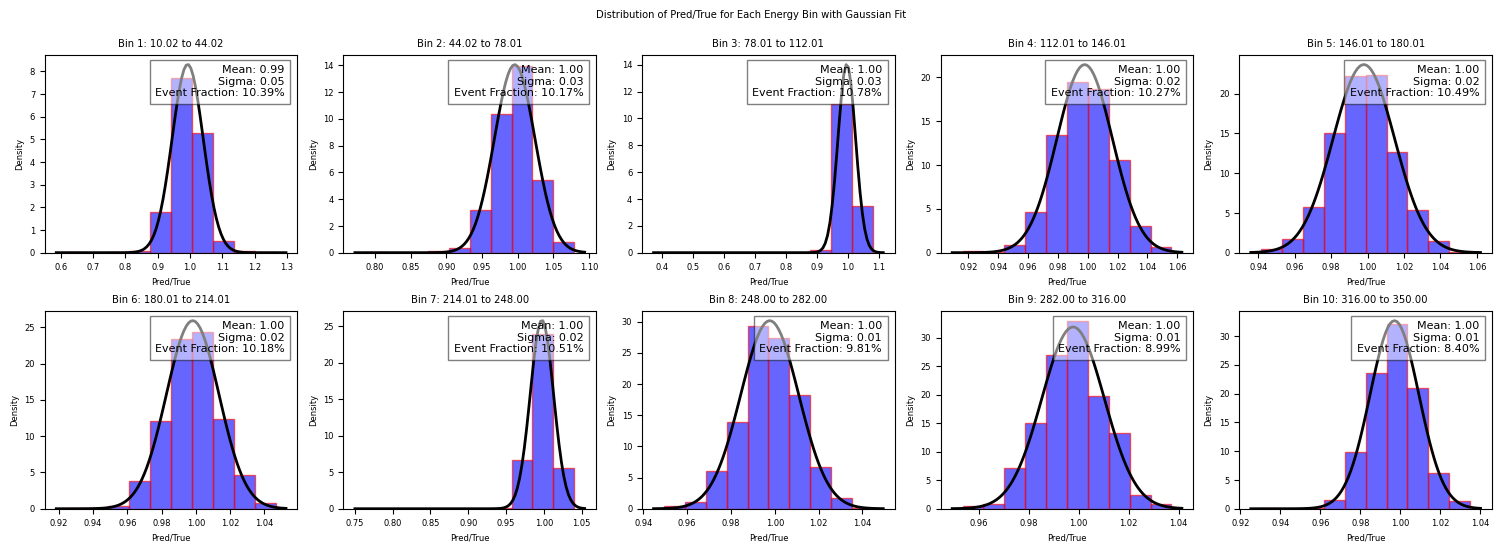

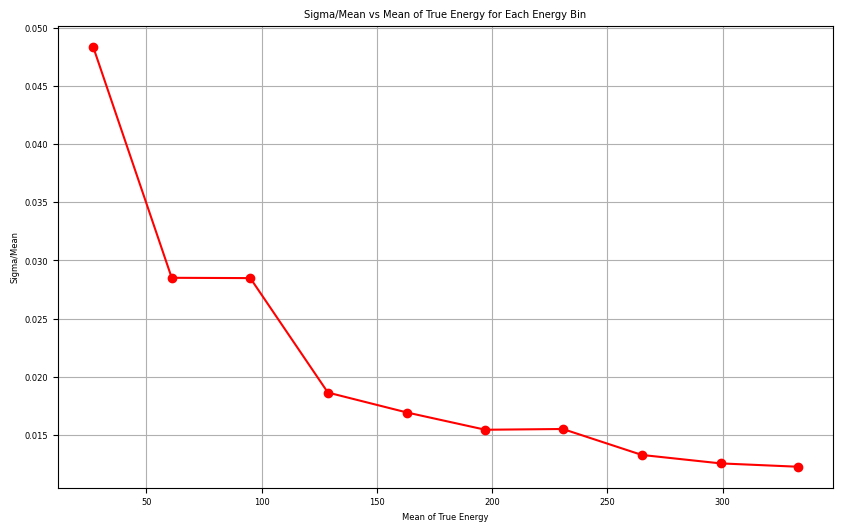

Means of True Energy: [26.95575369825666, 61.04226728669618, 95.12460274848652, 128.7948864361312, 163.11828240806042, 197.09162847080927, 230.67868615071959, 265.0019238613901, 299.18589274663174, 332.56599126610587]
Means of Pred/True Ratios: [0.992546825497156, 0.9958245654517728, 0.9963958988153065, 0.9979255054439148, 0.9979543712138079, 0.9981559836201912, 0.9974780736264806, 0.9977009220216829, 0.9977719234441013, 0.9971147262784346]
Sigmas of Pred/True Ratios: [0.04803909903988466, 0.02838827372747519, 0.028378622709882628, 0.018590257674543115, 0.016876791617322598, 0.015398242230454785, 0.015453525475841716, 0.013226710797581911, 0.012502426455530478, 0.012209052647538965]
Event Fractions: [0.10386666666666666, 0.10166666666666667, 0.1078, 0.10273333333333333, 0.10486666666666666, 0.1018, 0.10513333333333333, 0.09813333333333334, 0.08993333333333334, 0.084]
Sigma/Mean Ratios: [0.048399831429436484, 0.028507304109932623, 0.028481272096386793, 0.018628903232885574, 0.0169113860

In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm

# Replace 'your_file.csv' with the path to your CSV file
file_path = Path("true_test_DNN_15K.csv")

# Read the CSV file into a DataFrame
df = pd.read_csv(file_path)

# Define the number of bins
num_bins = 10

# Create the histogram and get the bin edges
counts, bin_edges = np.histogram(df['true'], bins=num_bins)

# Create a list to store DataFrames for each bin
bin_dataframes = []

# Create arrays to store the mean and sigma for each bin
means = []
sigmas = []
mean_true_energies = []
event_fractions = []

# Calculate the total number of events
total_events = len(df)

# Create a figure for the subplots
plt.figure(figsize=(15, 10))

# Iterate over the bin edges to filter the data and plot the distribution
for i in range(len(bin_edges) - 1):
    bin_start = bin_edges[i]
    bin_end = bin_edges[i + 1]
    
    # Filter the DataFrame for the current bin
    bin_df = df[(df['true'] >= bin_start) & (df['true'] < bin_end)]
    
    # Store the filtered DataFrame in the list
    bin_dataframes.append(bin_df)
    
    # Calculate the ratio pred/true
    bin_df['ratio'] = bin_df['pred'] / bin_df['true']
    
    # Fit a Gaussian distribution to the ratio data
    mean, sigma = norm.fit(bin_df['ratio'])
    
    # Store the mean and sigma in the arrays
    means.append(mean)
    sigmas.append(sigma)
    
    # Calculate the mean of the true energy for the current bin
    mean_true_energy = bin_df['true'].mean()
    mean_true_energies.append(mean_true_energy)
    
    # Calculate the event fraction for the current bin
    event_fraction = len(bin_df) / total_events
    event_fractions.append(event_fraction)
    
    # Create a subplot for the current bin
    plt.subplot(4, 5, i + 1)
    # Plot the histogram
    plt.hist(bin_df['ratio'], bins=10, density=True, color='blue', edgecolor='red', alpha=0.6)
    # Plot the Gaussian fit
    xmin, xmax = plt.xlim()
    x = np.linspace(xmin, xmax, 100)
    p = norm.pdf(x, mean, sigma)
    plt.plot(x, p, 'k', linewidth=2)
    
    plt.xlabel('Pred/True')
    plt.ylabel('Density')
    plt.title(f'Bin {i+1}: {bin_start:.2f} to {bin_end:.2f}')
    
    # Add a stats box
    textstr = '\n'.join((
        f'Mean: {mean:.2f}',
        f'Sigma: {sigma:.2f}',
        f'Event Fraction: {event_fraction:.2%}'
    ))
    plt.text(0.95, 0.95, textstr, transform=plt.gca().transAxes, fontsize=8,
             verticalalignment='top', horizontalalignment='right', bbox=dict(facecolor='white', alpha=0.5))
    
    plt.tight_layout()

# Display the plots
plt.suptitle('Distribution of Pred/True for Each Energy Bin with Gaussian Fit', y=1.02)
plt.show()

# Calculate sigma/mean for each bin
sigma_over_mean = [sigma / mean for sigma, mean in zip(sigmas, means)]

# Plot sigma/mean as a function of the mean of true energy
plt.figure(figsize=(10, 6))
plt.plot(mean_true_energies, sigma_over_mean, marker='o', linestyle='-', color='r')
plt.xlabel('Mean of True Energy')
plt.ylabel('Sigma/Mean')
plt.title('Sigma/Mean vs Mean of True Energy for Each Energy Bin')
plt.grid(True)
plt.show()

# Print the means, sigmas, and event fractions
print("Means of True Energy:", mean_true_energies)
print("Means of Pred/True Ratios:", means)
print("Sigmas of Pred/True Ratios:", sigmas)
print("Event Fractions:", event_fractions)
print("Sigma/Mean Ratios:", sigma_over_mean)
